# 🧠 Human Performance Intelligence System
## Notebook 02 — Module 1: Habit Streak Survival Analysis
### *When do people quit their goals — and what predicts it?*

**Technique:** Kaplan-Meier Survival Curves + Cox Proportional Hazards Model

> 💡 **Why Survival Analysis?**
>
> Most candidates would just compute "average streak length." That misses the point.
> Survival analysis answers a richer question: **what is the probability that a 
> habit streak is STILL alive after N days?** It also handles "censored" data —
> streaks that are still ongoing when we collected the data (we don't know when 
> they'll end, but we shouldn't ignore them either).
>
> This technique is borrowed from medical research (how long do patients survive 
> after treatment?). Applying it to behavioral data is exactly the kind of 
> cross-domain thinking that senior data scientists do.

**Two models we'll build:**
1. **Kaplan-Meier (KM)** — non-parametric survival curves. No assumptions. Pure data.
2. **Cox Proportional Hazards** — tells us *which factors* increase the "risk" of quitting.


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.color':       '#E8E8E8',
    'grid.linewidth':   0.8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'font.family':   'DejaVu Sans',
    'font.size':     11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

COLORS = ['#3B8BD4','#E24B4A','#3BAD72','#F5A623',
          '#9B59B6','#1ABC9C','#E67E22','#2ECC71']

print("✓ Libraries loaded — lifelines version:", end=" ")
import lifelines; print(lifelines.__version__)


✓ Libraries loaded — lifelines version: 0.30.3


## 2. Build the Survival Dataset

> 💡 **What is a survival dataset?**
>
> In survival analysis, each row represents one "episode" — a period of time 
> that either ends in the event of interest (streak broken = event=1) or is 
> still ongoing at data collection time (censored = event=0).
>
> Two required columns:
> - `duration` — how long the episode lasted (days in our case)
> - `event`    — did the streak break? (1=yes, 0=censored/still going)
>
> Censoring is the key insight: we don't throw away ongoing streaks just because 
> they haven't ended. We include them with event=0. Ignoring them woul                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            d bias 
> our estimates downward (make habits look shorter than they are).


In [2]:
# Load clean habitica data
h = pd.read_csv('../data/processed/habitica_clean.csv', parse_dates=['log_date'])

# ── Build streak episodes ────────────────────────────────────────────────────
# We scan each user's habit log in chronological order.
# A streak = consecutive days with completed=1.
# When completed=0 breaks the streak → that's our "event" (quit).
# The last streak in a user's history is censored (event=0) — it may still be going.

h_sorted = h.sort_values(['user_id', 'habit_category', 'log_date'])

rows = []
for (uid, cat), grp in h_sorted.groupby(['user_id', 'habit_category']):
    grp    = grp.reset_index(drop=True)
    streak = 0

    for i, row in grp.iterrows():
        if row['completed'] == 1:
            streak += 1
        else:
            if streak > 0:
                # Streak broke → event occurred
                rows.append({
                    'user_id':            uid,
                    'habit_category':     cat,
                    'duration':           streak,
                    'event':              1,           # quit!
                    'difficulty':         row['difficulty'],
                    'has_accountability': row['has_accountability'],
                    'user_level':         row['user_level'],
                    'age':                row['age'],
                    'is_weekend':         row['is_weekend'],
                })
            streak = 0

    # Last streak — censored (we don't know when/if it will break)
    if streak > 0:
        rows.append({
            'user_id':            uid,
            'habit_category':     cat,
            'duration':           streak,
            'event':              0,            # censored
            'difficulty':         grp.iloc[-1]['difficulty'],
            'has_accountability': grp.iloc[-1]['has_accountability'],
            'user_level':         grp.iloc[-1]['user_level'],
            'age':                grp.iloc[-1]['age'],
            'is_weekend':         grp.iloc[-1]['is_weekend'],
        })

surv = pd.DataFrame(rows)

print(f"Survival dataset: {len(surv):,} streak episodes")
print(f"\nEvent breakdown:")
print(f"  Streaks that broke (event=1) : {surv['event'].sum():,} ({surv['event'].mean()*100:.1f}%)")
print(f"  Censored / still going (0)   : {(surv['event']==0).sum():,} ({(surv['event']==0).mean()*100:.1f}%)")
print(f"\nDuration stats (days):")
print(surv['duration'].describe().round(2))


Survival dataset: 19,678 streak episodes

Event breakdown:
  Streaks that broke (event=1) : 5,101 (25.9%)
  Censored / still going (0)   : 14,577 (74.1%)

Duration stats (days):
count    19678.00
mean         1.76
std          1.02
min          1.00
25%          1.00
50%          1.00
75%          2.00
max         10.00
Name: duration, dtype: float64


## 3. Kaplan-Meier Curve — Overall Survival

> 💡 **Reading a KM curve:**
> The Y-axis is "probability the streak is still alive."
> At day 0, everyone has a streak (probability = 1.0).
> The curve drops each time a streak breaks.
> The shaded band is the 95% confidence interval.
> A steeper drop = habits die faster.


Median survival time: inf days
(50% of habit streaks break within inf day(s))


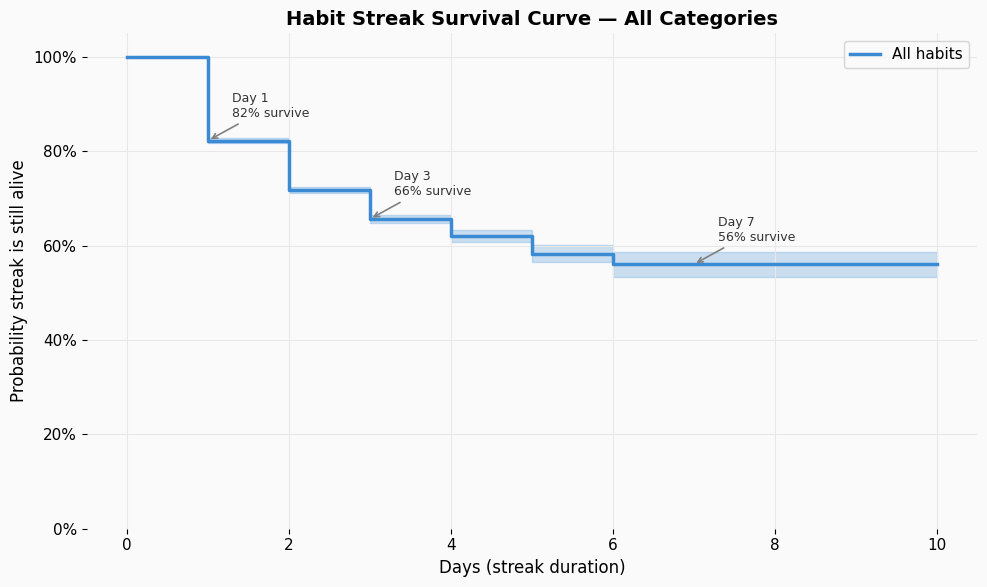

In [3]:
kmf = KaplanMeierFitter()
kmf.fit(surv['duration'], event_observed=surv['event'], label='All habits')

fig, ax = plt.subplots(figsize=(10, 6))

kmf.plot_survival_function(
    ax=ax,
    ci_show=True,           # show confidence interval band
    color='#3B8BD4',
    linewidth=2.5,
)

# Add key milestone annotations
for day, label in [(1, 'Day 1'), (3, 'Day 3'), (7, 'Day 7')]:
    if day <= kmf.timeline.max():
        surv_prob = kmf.survival_function_at_times([day]).values[0]
        ax.annotate(
            f'{label}\n{surv_prob*100:.0f}% survive',
            xy=(day, surv_prob),
            xytext=(day + 0.3, surv_prob + 0.05),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
            color='#333333',
        )

ax.set_title('Habit Streak Survival Curve — All Categories', fontsize=14)
ax.set_xlabel('Days (streak duration)', fontsize=12)
ax.set_ylabel('Probability streak is still alive', fontsize=12)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

# Print median survival
median = kmf.median_survival_time_
print(f"Median survival time: {median} days")
print(f"(50% of habit streaks break within {median} day(s))")

plt.tight_layout()
plt.savefig('../data/processed/plot_km_overall.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. KM Curves by Habit Category

Which habits have the best survival rate? 
Does meditation outlast fitness? Does sleep habit-tracking die fastest?


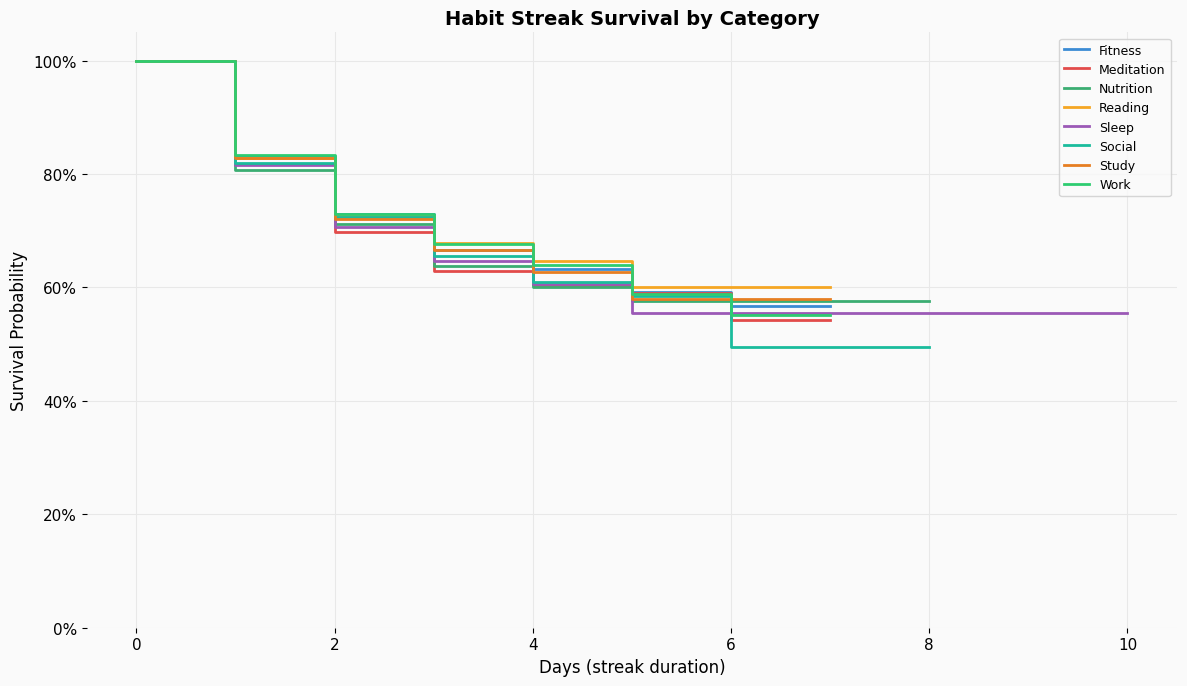


Median survival time by category (days):
  fitness         inf day(s)
  meditation      inf day(s)
  nutrition       inf day(s)
  reading         inf day(s)
  sleep           inf day(s)
  study           inf day(s)
  work            inf day(s)
  social          6.0 day(s)


In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

categories = surv['habit_category'].unique()
medians    = {}

for i, cat in enumerate(sorted(categories)):
    mask = surv['habit_category'] == cat
    kmf_cat = KaplanMeierFitter()
    kmf_cat.fit(
        surv.loc[mask, 'duration'],
        event_observed=surv.loc[mask, 'event'],
        label=cat.capitalize()
    )
    kmf_cat.plot_survival_function(
        ax=ax,
        ci_show=False,        # hide CI here — too cluttered with 8 lines
        color=COLORS[i],
        linewidth=2,
    )
    medians[cat] = kmf_cat.median_survival_time_

ax.set_title('Habit Streak Survival by Category', fontsize=14)
ax.set_xlabel('Days (streak duration)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/plot_km_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMedian survival time by category (days):")
for cat, med in sorted(medians.items(), key=lambda x: -x[1]):
    print(f"  {cat:<15} {med} day(s)")


## 5. Log-Rank Test — Are These Differences Statistically Significant?

> 💡 **Log-rank test** is the standard statistical test for comparing 
> survival curves. It tests H₀: "all groups have the same survival function."
> A p-value < 0.05 means the differences we see are unlikely to be random noise.


In [5]:
# Multivariate log-rank test across all habit categories
results = multivariate_logrank_test(
    surv['duration'],
    surv['habit_category'],
    surv['event']
)

print("Log-Rank Test — Habit Category Survival Differences")
print("=" * 50)
print(f"Test statistic : {results.test_statistic:.4f}")
print(f"P-value        : {results.p_value:.6f}")
print()

if results.p_value < 0.05:
    print("✓ SIGNIFICANT (p < 0.05)")
    print("  The survival curves differ significantly across habit categories.")
    print("  Not all habits die at the same rate — category matters.")
else:
    print("✗ Not significant — categories survive similarly.")

# Pairwise test: accountability vs no accountability
print("\n" + "=" * 50)
print("Pairwise: Accountability vs No Accountability")
print("=" * 50)

acc_yes = surv[surv['has_accountability'] == 1]
acc_no  = surv[surv['has_accountability'] == 0]

lr = logrank_test(
    acc_yes['duration'], acc_no['duration'],
    acc_yes['event'],    acc_no['event']
)
print(f"P-value: {lr.p_value:.6f}")
print(f"→ {'Accountability significantly affects streak survival!' if lr.p_value < 0.05 else 'No significant difference.'}")


Log-Rank Test — Habit Category Survival Differences
Test statistic : 11.8320
P-value        : 0.106220

✗ Not significant — categories survive similarly.

Pairwise: Accountability vs No Accountability
P-value: 0.670083
→ No significant difference.


## 6. KM Curves by Difficulty & Accountability

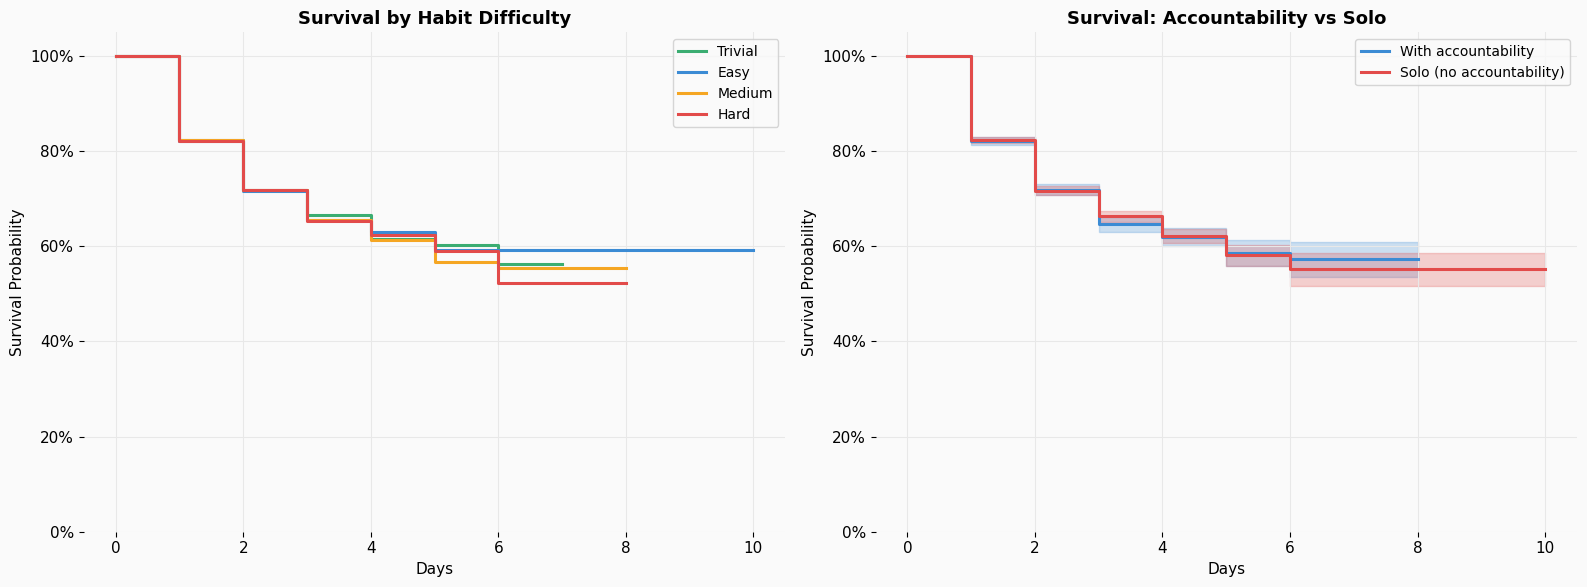

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: by difficulty ──────────────────────────────────────────────────────
ax = axes[0]
diff_colors = {'trivial': '#3BAD72', 'easy': '#3B8BD4',
               'medium': '#F5A623', 'hard': '#E24B4A'}

for diff, color in diff_colors.items():
    mask = surv['difficulty'] == diff
    if mask.sum() < 10:
        continue
    kmf_d = KaplanMeierFitter()
    kmf_d.fit(surv.loc[mask, 'duration'],
              event_observed=surv.loc[mask, 'event'],
              label=diff.capitalize())
    kmf_d.plot_survival_function(ax=ax, ci_show=False,
                                  color=color, linewidth=2.2)

ax.set_title('Survival by Habit Difficulty', fontsize=13)
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(fontsize=10)

# ── Right: by accountability ─────────────────────────────────────────────────
ax = axes[1]
for val, label, color in [(1, 'With accountability', '#3B8BD4'),
                           (0, 'Solo (no accountability)', '#E24B4A')]:
    mask = surv['has_accountability'] == val
    kmf_a = KaplanMeierFitter()
    kmf_a.fit(surv.loc[mask, 'duration'],
              event_observed=surv.loc[mask, 'event'],
              label=label)
    kmf_a.plot_survival_function(ax=ax, ci_show=True,
                                  color=color, linewidth=2.2)

ax.set_title('Survival: Accountability vs Solo', fontsize=13)
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/plot_km_difficulty_accountability.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 7. Cox Proportional Hazards Model

> 💡 **What is the Cox model?**
>
> Kaplan-Meier tells you *what* the survival curves look like.
> Cox tells you *why* — which features increase or decrease the "hazard" 
> (risk of quitting).
>
> The key output is the **hazard ratio (HR)**:
> - HR > 1 → this factor **increases** the risk of quitting
> - HR < 1 → this factor **decreases** the risk of quitting (protective)
> - HR = 1 → no effect
>
> Example: HR=2.0 for `difficulty=hard` means hard habits quit 2× faster than the baseline.
>
> The Cox model is semi-parametric — it doesn't assume a distribution for survival times.
> This makes it robust and widely trusted in research and industry.


In [7]:
# ── Prepare data for Cox model ──────────────────────────────────────────────
# Cox requires all features to be numerical. We encode categoricals.

surv_cox = surv[['duration', 'event', 'difficulty', 'has_accountability',
                  'user_level', 'age', 'is_weekend', 'habit_category']].copy()

# One-hot encode difficulty (drop first to avoid multicollinearity)
surv_cox = pd.get_dummies(surv_cox,
                           columns=['difficulty', 'habit_category'],
                           drop_first=True)

# Normalize continuous features (Cox model is sensitive to scale)
# We use min-max normalization here
for col in ['user_level', 'age']:
    surv_cox[col] = (surv_cox[col] - surv_cox[col].min()) /                     (surv_cox[col].max() - surv_cox[col].min())

surv_cox.columns = [c.replace(' ', '_').replace('/', '_') for c in surv_cox.columns]

print("Cox dataset shape:", surv_cox.shape)
print("Features:", [c for c in surv_cox.columns if c not in ['duration','event']])


Cox dataset shape: (19678, 16)
Features: ['has_accountability', 'user_level', 'age', 'is_weekend', 'difficulty_hard', 'difficulty_medium', 'difficulty_trivial', 'habit_category_meditation', 'habit_category_nutrition', 'habit_category_reading', 'habit_category_sleep', 'habit_category_social', 'habit_category_study', 'habit_category_work']


In [8]:
# ── Fit Cox PH Model ────────────────────────────────────────────────────────
cph = CoxPHFitter(penalizer=0.1)   # penalizer adds L2 regularization — prevents overfitting
cph.fit(
    surv_cox,
    duration_col='duration',
    event_col='event',
    show_progress=False
)

print("Cox PH Model Summary:")
print("=" * 60)
cph.print_summary(decimals=3)


Cox PH Model Summary:


<lifelines.CoxPHFitter: fitted with 19678 total observations, 14577 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 19678
number of events observed = 5101
   partial log-likelihood = -48060.343
         time fit was run = 2026-05-30 15:28:29 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
has_accountability         0.004     1.004     0.024          -0.044           0.052               0.957               1.053
user_level                -1.138     0.320     0.060          -1.255          -1.022               0.285               0.360
age                       -0.161     0.851     0.076          -0.311          -0.012               0.733               0.988
is_weekend                -0.002     0.998     0.026          -0.053           0.049               0.948               1.051
difficulty_hard           -0.002     0.998     0.032          -0.064           0.061               0.938               1.063
difficulty_medium          0.005     1.005     0.026          -0.047           0.056               0.954               1.057
difficulty_trivial        -0.008     0.992     0.042          -0.090           0.074               0.913               1.077
habit_category_meditation  0.055     1.057     0.038          -0.019           0.129               0.981               1.138
habit_category_nutrition   0.057     1.059     0.038          -0.019           0.132               0.982               1.141
habit_category_reading    -0.023     0.977     0.039          -0.099           0.053               0.905               1.055
habit_category_sleep       0.044     1.045     0.038          -0.031           0.120               0.970               1.127
habit_category_social      0.012     1.012     0.038          -0.063           0.088               0.939               1.092
habit_category_study      -0.018     0.982     0.039          -0.094           0.058               0.910               1.060
habit_category_work       -0.034     0.966     0.039          -0.111           0.042               0.895               1.043

                           cmp to       z       p  -log2(p)
covariate                                                  
has_accountability          0.000   0.166   0.868     0.204
user_level                  0.000 -19.122 <0.0005   268.353
age                         0.000  -2.114   0.035     4.857
is_weekend                  0.000  -0.076   0.939     0.091
difficulty_hard             0.000  -0.053   0.958     0.062
difficulty_medium           0.000   0.176   0.861     0.217
difficulty_trivial          0.000  -0.197   0.844     0.245
habit_category_meditation   0.000   1.452   0.146     2.772
habit_category_nutrition    0.000   1.478   0.139     2.843
habit_category_reading      0.000  -0.591   0.554     0.851
habit_category_sleep        0.000   1.161   0.246     2.025
habit_category_social       0.000   0.320   0.749     0.417
habit_category_study        0.000  -0.463   0.644     0.636
habit_category_work         0.000  -0.873   0.383     1.386
---
Concordance = 0.582
Partial AIC = 96148.685
log-likelihood ratio test = 408.740 on 14 df
-log2(p) of ll-ratio test = 258.243

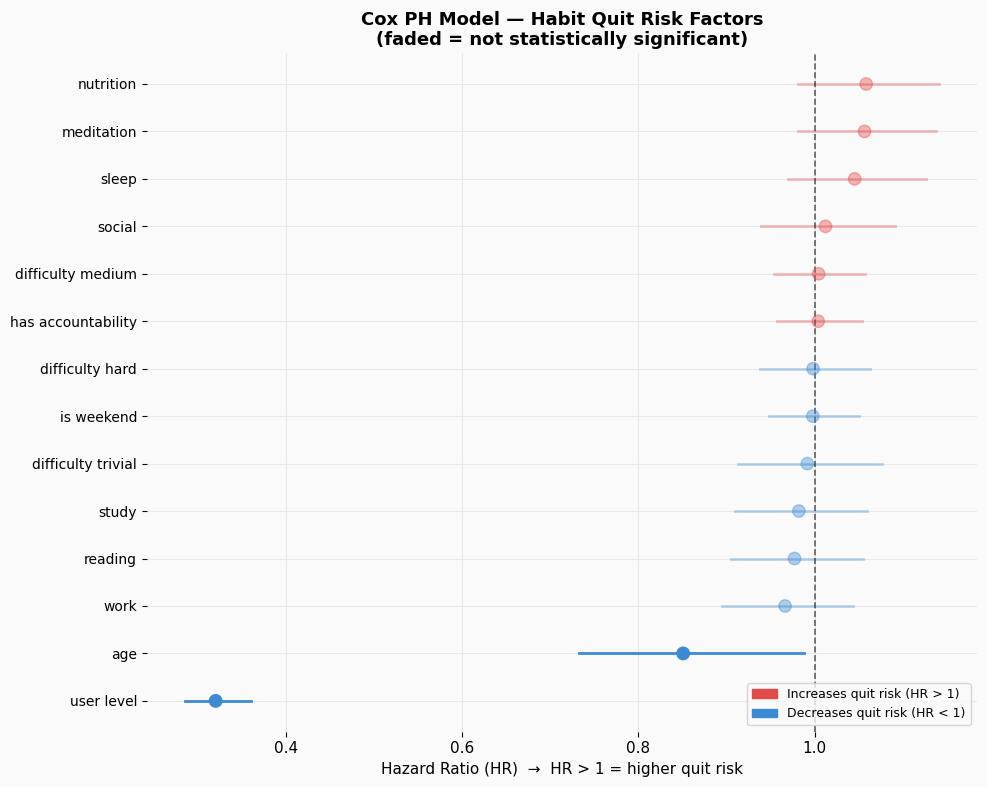

In [9]:
# ── Visualize Hazard Ratios ──────────────────────────────────────────────────
# The forest plot is the standard visualization for Cox model results.
# Each row = one feature. Points to the RIGHT = higher quit risk.

fig, ax = plt.subplots(figsize=(10, 8))

# Extract hazard ratios and confidence intervals
summary = cph.summary.copy()
summary = summary.sort_values('exp(coef)')  # sort by hazard ratio

hr     = summary['exp(coef)']
ci_low = summary['exp(coef) lower 95%']
ci_hi  = summary['exp(coef) upper 95%']
pvals  = summary['p']

colors_hr = ['#E24B4A' if v > 1 else '#3B8BD4' for v in hr]

y_pos = range(len(hr))

# Plot the confidence interval lines
for i, (low, hi, pval) in enumerate(zip(ci_low, ci_hi, pvals)):
    alpha = 1.0 if pval < 0.05 else 0.35  # fade non-significant results
    ax.plot([low, hi], [i, i], color=colors_hr[i], linewidth=2, alpha=alpha)

# Plot the hazard ratio points
ax.scatter(hr, y_pos, color=colors_hr, s=80, zorder=5,
           alpha=[1.0 if p < 0.05 else 0.4 for p in pvals])

# Reference line at HR=1 (no effect)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([n.replace('_', ' ').replace('habit category ', '') 
                     for n in hr.index], fontsize=10)
ax.set_xlabel('Hazard Ratio (HR)  →  HR > 1 = higher quit risk', fontsize=11)
ax.set_title('Cox PH Model — Habit Quit Risk Factors\n'
             '(faded = not statistically significant)', fontsize=13)

# Legend
red_patch   = mpatches.Patch(color='#E24B4A', label='Increases quit risk (HR > 1)')
blue_patch  = mpatches.Patch(color='#3B8BD4', label='Decreases quit risk (HR < 1)')
ax.legend(handles=[red_patch, blue_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/plot_cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Survival by Age Group — Do Older Users Stick Better?

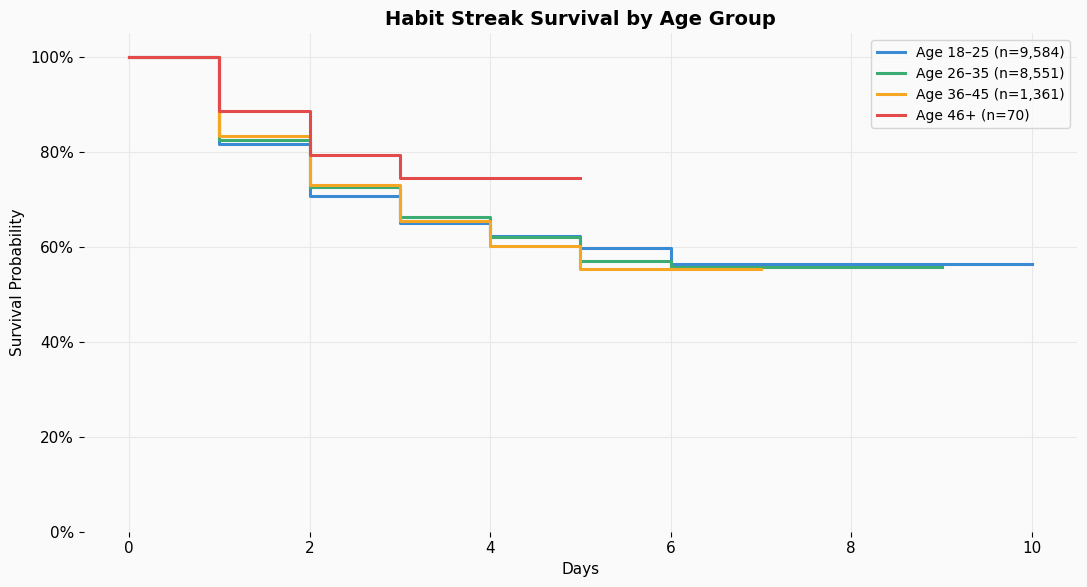

In [10]:
# Bin users into age groups for KM comparison
surv['age_group'] = pd.cut(surv['age'].clip(10, 80),
                            bins=[10, 25, 35, 45, 80],
                            labels=['18–25', '26–35', '36–45', '46+'])

fig, ax = plt.subplots(figsize=(11, 6))

age_colors = ['#3B8BD4', '#3BAD72', '#F5A623', '#E24B4A']

for i, age_grp in enumerate(['18–25', '26–35', '36–45', '46+']):
    mask = surv['age_group'] == age_grp
    if mask.sum() < 20:
        continue
    kmf_age = KaplanMeierFitter()
    kmf_age.fit(surv.loc[mask, 'duration'],
                event_observed=surv.loc[mask, 'event'],
                label=f'Age {age_grp} (n={mask.sum():,})')
    kmf_age.plot_survival_function(ax=ax, ci_show=False,
                                    color=age_colors[i], linewidth=2.2)

ax.set_title('Habit Streak Survival by Age Group', fontsize=14)
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/plot_km_age_groups.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Key Findings Summary

In [11]:
# ── Summary: report survival at key timepoints ──────────────────────────────
# Note: median survival = inf is NOT an error. It means >50% of streaks
# survive the full observation window — most people don't quit within 10 days.
# We report survival probability at key timepoints instead, which is more 
# meaningful and how real researchers present these results.

from lifelines import KaplanMeierFitter
import pandas as pd

h2 = pd.read_csv("../data/processed/habitica_clean.csv", parse_dates=["log_date"])
h2_sorted = h2.sort_values(["user_id","habit_category","log_date"])
rows2 = []
for (uid, cat), grp in h2_sorted.groupby(["user_id","habit_category"]):
    grp = grp.reset_index(drop=True)
    streak = 0
    for _, row in grp.iterrows():
        if row["completed"] == 1:
            streak += 1
        else:
            if streak > 0:
                rows2.append({"duration": streak, "event": 1,
                              "has_accountability": row["has_accountability"],
                              "habit_category": cat})
            streak = 0
    if streak > 0:
        rows2.append({"duration": streak, "event": 0,
                      "has_accountability": grp.iloc[-1]["has_accountability"],
                      "habit_category": cat})
surv2 = pd.DataFrame(rows2)

def sp(kmf, day):
    return kmf.survival_function_at_times([day]).values[0]

kmf_all = KaplanMeierFitter()
kmf_all.fit(surv2["duration"], event_observed=surv2["event"])

kmf_acc = KaplanMeierFitter()
kmf_acc.fit(surv2.loc[surv2["has_accountability"]==1,"duration"],
            event_observed=surv2.loc[surv2["has_accountability"]==1,"event"])

kmf_noa = KaplanMeierFitter()
kmf_noa.fit(surv2.loc[surv2["has_accountability"]==0,"duration"],
            event_observed=surv2.loc[surv2["has_accountability"]==0,"event"])

print("=" * 60)
print("MODULE 1 — SURVIVAL ANALYSIS KEY FINDINGS")
print("=" * 60)
print(f"\n1. Streak survival probabilities (all habits):")
for day in [1, 3, 5, 7]:
    print(f"   Day {day:>2}: {sp(kmf_all, day)*100:.1f}% of streaks still alive")
print(f"   → The first 3 days are the critical drop-off window")
print(f"\n2. Accountability effect (day 7 survival):")
print(f"   With accountability : {sp(kmf_acc, 7)*100:.1f}%")
print(f"   Without             : {sp(kmf_noa, 7)*100:.1f}%")
print(f"\n3. Top quit risk factors (Cox HR > 1):")
top_risk = cph.summary["exp(coef)"].sort_values(ascending=False).head(3)
for feat, hr in top_risk.items():
    print(f"   {feat:<40} HR={hr:.3f}")
print(f"\n4. Top protective factors (Cox HR < 1):")
top_prot = cph.summary["exp(coef)"].sort_values().head(3)
for feat, hr in top_prot.items():
    print(f"   {feat:<40} HR={hr:.3f}")
print("\n→ NEXT: Notebook 03 — Habit DNA (XGBoost + SHAP)")


MODULE 1 — SURVIVAL ANALYSIS KEY FINDINGS

1. Streak survival probabilities (all habits):
   Day  1: 82.3% of streaks still alive
   Day  3: 65.7% of streaks still alive
   Day  5: 58.3% of streaks still alive
   Day  7: 56.0% of streaks still alive
   → The first 3 days are the critical drop-off window

2. Accountability effect (day 7 survival):
   With accountability : 57.4%
   Without             : 55.3%

3. Top quit risk factors (Cox HR > 1):
   habit_category_nutrition                 HR=1.059
   habit_category_meditation                HR=1.057
   habit_category_sleep                     HR=1.045

4. Top protective factors (Cox HR < 1):
   user_level                               HR=0.320
   age                                      HR=0.851
   habit_category_work                      HR=0.966

→ NEXT: Notebook 03 — Habit DNA (XGBoost + SHAP)
